## Импорты

In [141]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_log_error, mean_squared_error
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

## Функция предобработки

In [123]:
def preprocess_data(df, is_train=True):
    df = df.copy()
    
    # Категориальные признаки
    cat_cols = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
    
    # Числовые признаки (исключаем целевую и неиспользуемые)
    exclude = ['id', 'timestamp', 'price_doc']
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in exclude]
    
    # Заполнение пропусков медианой по району
    for col in num_cols:
        df[col] = df.groupby('sub_area')[col].transform(lambda x: x.fillna(x.median()))
    
    # Оставшиеся пропуски заполняем глобальной медианой
    if num_cols:
        global_medians = df[num_cols].median()
        for col in num_cols:
            df[col] = df[col].fillna(global_medians[col])
    
    # Обработка build_year
    df['build_year'] = df['build_year'].apply(lambda x: x if 1600 < x < 2024 else np.nan)
    df['build_year'] = df.groupby('sub_area')['build_year'].transform(lambda x: x.fillna(x.median()))
    
    # === НОВЫЕ ПРИЗНАКИ БЕЗ ФРАГМЕНТАЦИИ ===
    new_features = pd.DataFrame({
        'age': df['timestamp'].dt.year - df['build_year'],
        'life_sq_ratio': df['life_sq'] / df['full_sq'],
        'kitch_sq_ratio': df['kitch_sq'] / df['full_sq'],
        'floor_ratio': df['floor'] / df['max_floor']
    }, index=df.index)
    
    # Заменяем бесконечности и NaN
    new_features = new_features.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Объединяем с исходным DataFrame
    df = pd.concat([df, new_features], axis=1)
    
    return df

# Пункт 1. Обучение baseline модели (1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

Шаблон кода по разбиению на train/test:
```
import pandas as pd

df = pd.read_csv("./data/train.csv")
df_train = df[df["timestamp"] < "2015-01-01"]
df_test = df["2015-01-01" <= df["timestamp"]]
```

## Загрузка и объединение данных

In [75]:
DATA_PATH = Path("resources")

train = pd.read_csv(DATA_PATH / 'train.csv')
test = pd.read_csv(DATA_PATH / 'test.csv')
macro = pd.read_csv(DATA_PATH / 'macro.csv')

# Преобразование timestamp
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])
macro['timestamp'] = pd.to_datetime(macro['timestamp'])

# Присоединение макроэкономических показателей
train = train.merge(macro, on='timestamp', how='left')
test = test.merge(macro, on='timestamp', how='left')

# Разделение на train/validation по времени (согласно шаблону)
df_train = train[train['timestamp'] < '2015-01-01'].copy()
df_valid = train[train['timestamp'] >= '2015-01-01'].copy()


## Первичный анализ данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 391 entries, id to apartment_fund_sqm
dtypes: datetime64[ns](1), float64(213), int64(159), object(18)
memory usage: 90.9+ MB
None
                 id                      timestamp       full_sq  \
count  30471.000000                          30471  30471.000000   
mean   15237.917397  2013-12-21 16:45:41.911982080     54.214269   
min        1.000000            2011-08-20 00:00:00      0.000000   
25%     7620.500000            2013-04-25 00:00:00     38.000000   
50%    15238.000000            2014-02-19 00:00:00     49.000000   
75%    22855.500000            2014-09-24 00:00:00     63.000000   
max    30473.000000            2015-06-30 00:00:00   5326.000000   
std     8796.501536                            NaN     38.031487   

            life_sq         floor     max_floor      material    build_year  \
count  24088.000000  30304.000000  20899.000000  20899.000000  1.686600e+04   
mean      34.4

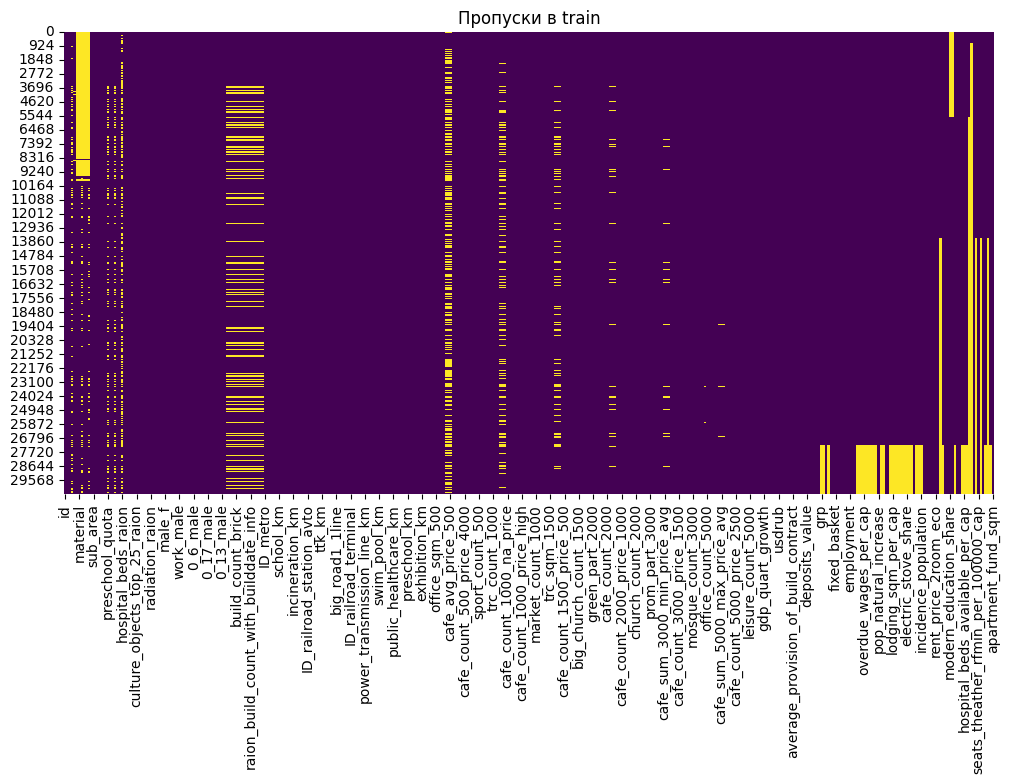

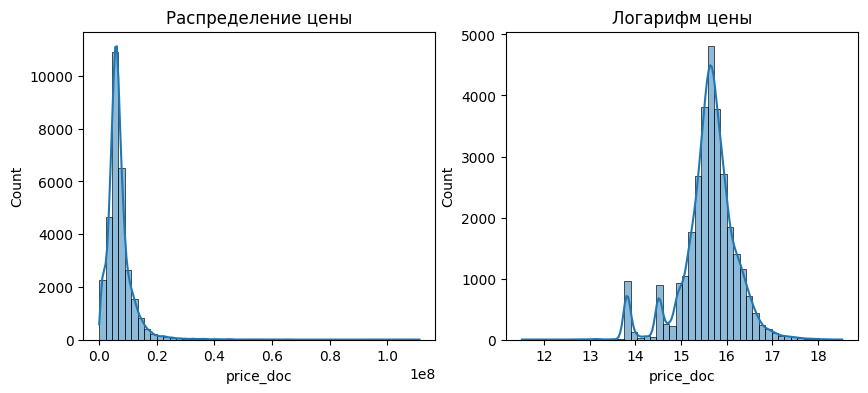

In [76]:
# Просмотр структуры
print(train.info())
print(train.describe())

# Визуализация пропусков
plt.figure(figsize=(12,6))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title('Пропуски в train')
plt.show()

# Распределение цены
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(train['price_doc'], bins=50, kde=True)
plt.title('Распределение цены')
plt.subplot(1,2,2)
sns.histplot(np.log1p(train['price_doc']), bins=50, kde=True)
plt.title('Логарифм цены')
plt.show()

## Обработка пропусков и выбросов

In [77]:
# Пример обработки числовых признаков
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('price_doc')

# Заполнение пропусков медианой по подгруппам sub_area
for col in num_cols:
    train[col] = train[col].fillna(train.groupby('sub_area')[col].transform('median'))
    test[col] = test[col].fillna(test.groupby('sub_area')[col].transform('median'))

# Для оставшихся пропусков — глобальная медиана
global_medians = train[num_cols].median()
train[num_cols] = train[num_cols].fillna(global_medians)
test[num_cols] = test[num_cols].fillna(global_medians)

# Категориальные признаки
cat_cols = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']  # и другие
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')
    test[col] = test[col].fillna('Unknown')

## Инжиниринг признаков

In [99]:
# Отсекаем аномальные года постройки
train['build_year'] = train['build_year'].where((train['build_year'] > 1600) & (train['build_year'] < 2024), np.nan)
test['build_year'] = test['build_year'].where((test['build_year'] > 1600) & (test['build_year'] < 2024), np.nan)

# Глобальные медианы для подстраховки (на случай пустых групп)
global_median_train = train['build_year'].median()
global_median_test = test['build_year'].median()

# Функция заполнения: если в группе все NaN – использовать глобальную медиану
def fill_build_year(series, global_median):
    group_median = series.median()
    if pd.isna(group_median):
        return series.fillna(global_median)
    else:
        return series.fillna(group_median)

# Заполняем пропуски в build_year медианой по району
train['build_year'] = train.groupby('sub_area')['build_year'].transform(
    lambda x: fill_build_year(x, global_median_train)
)
test['build_year'] = test.groupby('sub_area')['build_year'].transform(
    lambda x: fill_build_year(x, global_median_test)
)

# Создаём все новые признаки в виде словаря Series
new_train_features = {
    'age': train['timestamp'].dt.year - train['build_year'],
    'life_sq_ratio': train['life_sq'] / train['full_sq'],
    'kitch_sq_ratio': train['kitch_sq'] / train['full_sq'],
    'floor_ratio': train['floor'] / train['max_floor']
}

new_test_features = {
    'age': test['timestamp'].dt.year - test['build_year'],
    'life_sq_ratio': test['life_sq'] / test['full_sq'],
    'kitch_sq_ratio': test['kitch_sq'] / test['full_sq'],
    'floor_ratio': test['floor'] / test['max_floor']
}

# Добавляем все признаки сразу, чтобы избежать фрагментации
train = pd.concat([train, pd.DataFrame(new_train_features)], axis=1)
test = pd.concat([test, pd.DataFrame(new_test_features)], axis=1)

## Подготовка признаков для модели

In [79]:
# Целевая переменная
y_train = np.log1p(df_train['price_doc'])
y_valid = np.log1p(df_valid['price_doc'])

# Признаки (исключаем id, timestamp, price_doc)
feature_cols = [col for col in df_train.columns if col not in ['id', 'timestamp', 'price_doc']]

X_train = df_train[feature_cols].copy()
X_valid = df_valid[feature_cols].copy()
X_test = test[feature_cols].copy()

# Убедимся, что все пропуски обработаны (только для числовых колонок)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
X_train[num_cols] = X_train[num_cols].fillna(0)
X_valid[num_cols] = X_valid[num_cols].fillna(0)
X_test[num_cols] = X_test[num_cols].fillna(0)

## Обучение модели

In [80]:
# Исходные категориальные признаки
initial_cat_features = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']

# Определяем все столбцы типа object в обучающей выборке
object_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Объединяем и убираем дубликаты
cat_features = list(set(initial_cat_features + object_cols))

# Приводим все категориальные признаки к типу 'category'
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')
    
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=63,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01, 
    reg_lambda=0.01,
    min_child_samples=20,
    min_split_gain=0.0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    categorical_feature=cat_features   # передаём полный список
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 44007
[LightGBM] [Info] Number of data points in the train set: 27232, number of used features: 388
[LightGBM] [Info] Start training from score 15.592357
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.405934	valid_0's l2: 0.164782
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,10
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

## Оценка качества

In [86]:
pred_valid = model.predict(X_valid)
# Метрика RMSLE (так как мы предсказывали логарифм)
rmsle = np.sqrt(mean_squared_error(y_valid, pred_valid))
print(f'RMSLE на валидации: {rmsle}')

# Для интерпретации можно вернуться к исходным ценам
pred_price = np.expm1(pred_valid)
actual_price = np.expm1(y_valid)
rmsle_original = np.sqrt(mean_squared_log_error(actual_price, pred_price))
print(f'RMSLE в исходных ценах: {rmsle_original}')

RMSLE на валидации: 0.40451726065905175
RMSLE в исходных ценах: 0.40451726065905175


## Важность признаков

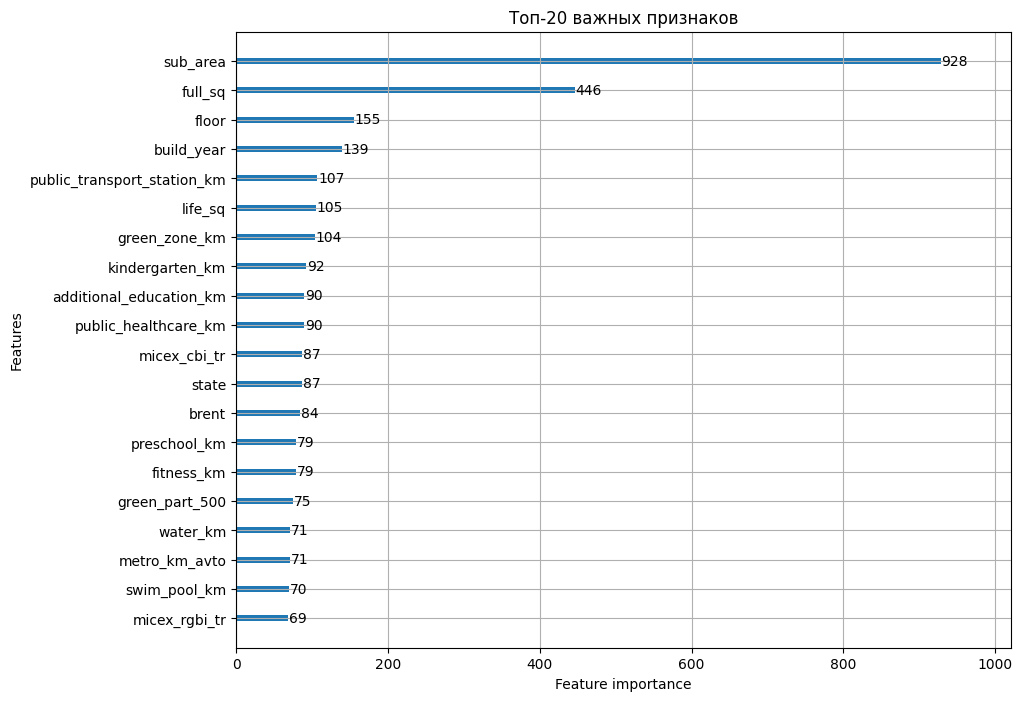

In [89]:
lgb.plot_importance(model, max_num_features=20, figsize=(10,8))
plt.title('Топ-20 важных признаков')
plt.show()

# Пункт 2. Улучшение baseline (1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

## Базовая модель

In [104]:
# Выбор простых признаков
baseline_features = ['full_sq', 'life_sq', 'floor', 'max_floor', 'build_year', 'num_room', 'kitch_sq', 'state']

# Удалим строки с пропусками в этих признаках (для простоты)
baseline_train = df_train[baseline_features + ['price_doc']].dropna()
baseline_valid = df_valid[baseline_features + ['price_doc']].dropna()

X_train_base = baseline_train[baseline_features]
y_train_base = np.log1p(baseline_train['price_doc'])
X_valid_base = baseline_valid[baseline_features]
y_valid_base = np.log1p(baseline_valid['price_doc'])

# Обучение линейной регрессии
lr = LinearRegression()
lr.fit(X_train_base, y_train_base)
pred_base = lr.predict(X_valid_base)

# Метрика RMSLE (так как работаем с логарифмом, RMSLE = RMSE логарифмов)
rmsle_base = np.sqrt(((pred_base - y_valid_base) ** 2).mean())
print(f"Baseline RMSLE: {rmsle_base:.5f}")

Baseline RMSLE: 0.52738


## Улучшенная модель

In [112]:
# Применяем предобработку
train_processed = preprocess_data(df_train)
valid_processed = preprocess_data(df_valid)
test_processed = preprocess_data(test)

# Преобразование всех object-колонок в категориальные
for df in [train_processed, valid_processed, test_processed]:
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    for col in object_cols:
        df[col] = df[col].astype('category')

# Целевая переменная
y_train_imp = np.log1p(train_processed['price_doc'])
y_valid_imp = np.log1p(valid_processed['price_doc'])

# Признаки (исключаем id, timestamp, price_doc)
feature_cols = [c for c in train_processed.columns if c not in ['id', 'timestamp', 'price_doc']]
X_train_imp = train_processed[feature_cols]
X_valid_imp = valid_processed[feature_cols]

# Определяем категориальные признаки (теперь все колонки типа category)
cat_features = X_train_imp.select_dtypes(include=['category']).columns.tolist()

# Модель LightGBM
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

model.fit(
    X_train_imp, y_train_imp,
    eval_set=[(X_valid_imp, y_valid_imp)],
    eval_metric='rmse',
    categorical_feature=cat_features,  # явно передаём список категориальных колонок
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

pred_imp = model.predict(X_valid_imp)
rmsle_imp = np.sqrt(((pred_imp - y_valid_imp) ** 2).mean())
print(f"Улучшенная модель RMSLE: {rmsle_imp:.5f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.406185	valid_0's l2: 0.164986
[200]	valid_0's rmse: 0.402879	valid_0's l2: 0.162312
Early stopping, best iteration is:
[212]	valid_0's rmse: 0.402689	valid_0's l2: 0.162159
Улучшенная модель RMSLE: 0.40269


## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

## Сравнение результатов

In [113]:
print(f"Baseline RMSLE: {rmsle_base:.5f}")
print(f"Улучшенная RMSLE: {rmsle_imp:.5f}")
improvement = (rmsle_base - rmsle_imp) / rmsle_base * 100
print(f"Улучшение: {improvement:.2f}%")

Baseline RMSLE: 0.52738
Улучшенная RMSLE: 0.40269
Улучшение: 23.64%


## Визуализация важности признаков

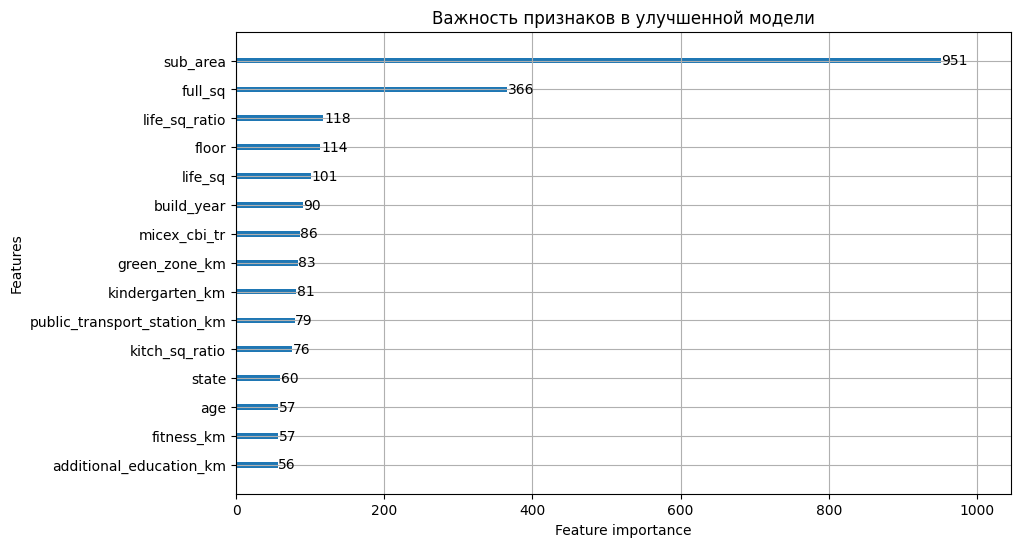

In [114]:
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6))
plt.title("Важность признаков в улучшенной модели")
plt.show()

# Пункт 3. Отбор признаков (1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

## Обучение полной модели и получение важности признаков

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[212]	valid_0's rmse: 0.402689	valid_0's l2: 0.162159
Топ-10 признаков по важности:
                         feature  importance
10                      sub_area         951
0                        full_sq         366
389                life_sq_ratio         118
2                          floor         114
1                        life_sq         101
5                     build_year          90
308                 micex_cbi_tr          86
90                 green_zone_km          83
87               kindergarten_km          81
101  public_transport_station_km          79


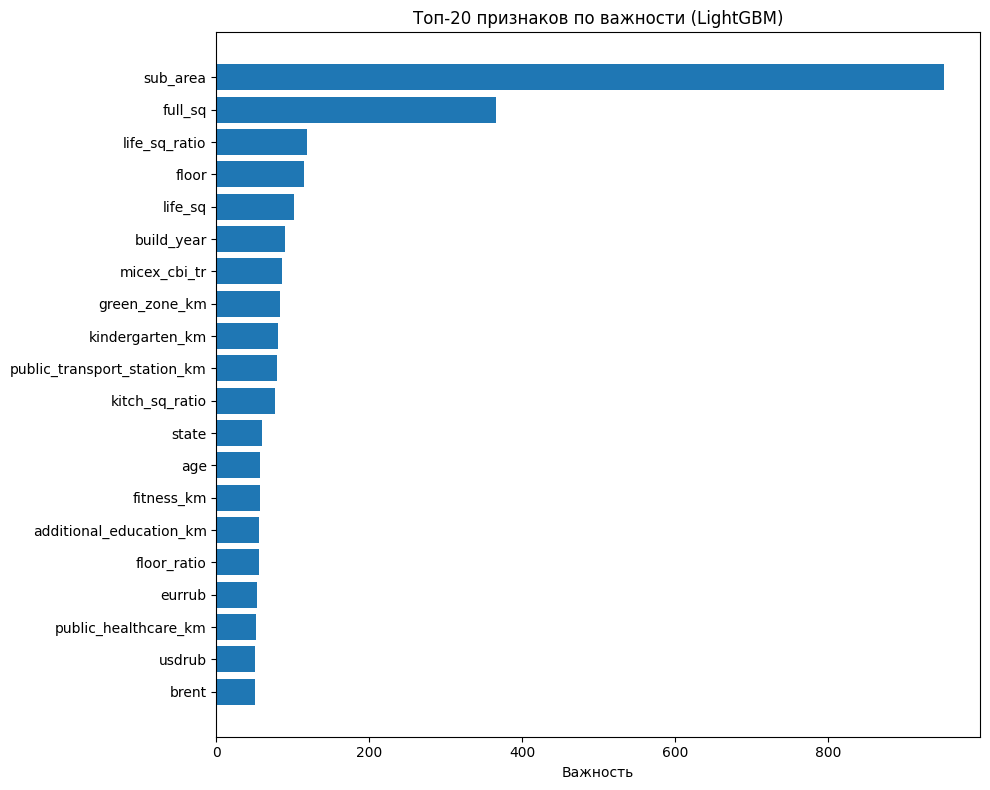

In [127]:
# Применяем предобработку
train_processed = preprocess_data(df_train)
valid_processed = preprocess_data(df_valid)

# === ДОБАВЛЕНО: преобразование object-колонок в категориальные ===
for df in [train_processed, valid_processed]:
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    for col in object_cols:
        df[col] = df[col].astype('category')

# Целевая переменная
y_train = np.log1p(train_processed['price_doc'])
y_valid = np.log1p(valid_processed['price_doc'])

# Признаки
feature_cols = [c for c in train_processed.columns if c not in ['id', 'timestamp', 'price_doc']]
X_train = train_processed[feature_cols]
X_valid = valid_processed[feature_cols]

# Категориальные признаки – теперь можно взять все колонки типа category
cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
# или оставить исходный список, но он может быть неполным:
# cat_features = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']
# cat_features = [c for c in cat_features if c in feature_cols]

# Модель
model_full = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

# Обучение с указанием категориальных признаков
model_full.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='rmse',
    categorical_feature=cat_features,   # <-- важно передать
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Важность признаков
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_full.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-10 признаков по важности:")
print(importance.head(10))

# Визуализация топ-20
plt.figure(figsize=(10, 8))
plt.barh(importance.head(20)['feature'], importance.head(20)['importance'])
plt.xlabel('Важность')
plt.title('Топ-20 признаков по важности (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Отбор признаков (топ-30)

In [130]:
top_k = 30
selected_features = importance.head(top_k)['feature'].tolist()
print(f"Отобрано {len(selected_features)} признаков: {selected_features}")

Отобрано 30 признаков: ['sub_area', 'full_sq', 'life_sq_ratio', 'floor', 'life_sq', 'build_year', 'micex_cbi_tr', 'green_zone_km', 'kindergarten_km', 'public_transport_station_km', 'kitch_sq_ratio', 'state', 'age', 'fitness_km', 'additional_education_km', 'floor_ratio', 'eurrub', 'public_healthcare_km', 'usdrub', 'brent', 'metro_min_avto', 'green_part_1000', 'green_part_500', 'catering_km', 'micex', 'school_km', 'cpi', 'metro_km_avto', 'ppi', 'rts']


## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

## Обучение модели только на отобранных признаках

In [131]:
X_train_sel = X_train[selected_features]
X_valid_sel = X_valid[selected_features]

# Убедимся, что среди отобранных есть категориальные, и передадим их в модель
cat_features_sel = [c for c in cat_features if c in selected_features]

model_sel = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

model_sel.fit(
    X_train_sel, y_train,
    eval_set=[(X_valid_sel, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    categorical_feature=cat_features_sel
)

# Предсказание и метрика
pred_sel = model_sel.predict(X_valid_sel)
rmsle_sel = np.sqrt(mean_squared_error(y_valid, pred_sel))

# Метрика полной модели (из предыдущего шага, можно пересчитать)
pred_full = model_full.predict(X_valid)
rmsle_full = np.sqrt(mean_squared_error(y_valid, pred_full))

print(f"RMSLE (полная модель, {len(feature_cols)} признаков): {rmsle_full:.5f}")
print(f"RMSLE (отобранные {top_k} признаков): {rmsle_sel:.5f}")
print(f"Изменение: {((rmsle_sel - rmsle_full)/rmsle_full)*100:.2f}%")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[217]	valid_0's rmse: 0.401745	valid_0's l2: 0.161399
RMSLE (полная модель, 392 признаков): 0.40269
RMSLE (отобранные 30 признаков): 0.40175
Изменение: -0.23%


# Пункт 4. Eval feature (опциональный пункт, 1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

## Создание нового признака (площадь / расстояние до метро)

In [145]:
for df in [train_processed, valid_processed]:
    df['sq_per_metro'] = (df['full_sq'] / (df['metro_km_walk'] + 0.1)).fillna(0)

# Далее подготовка данных
y_train = np.log1p(train_processed['price_doc'])
y_valid = np.log1p(valid_processed['price_doc'])

feature_cols = [c for c in train_processed.columns if c not in ['id', 'timestamp', 'price_doc']]
X_train = train_processed[feature_cols]
X_valid = valid_processed[feature_cols]

cat_features = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']
cat_features = [c for c in cat_features if c in feature_cols]

## Обучение модели с новым признаком

In [146]:
# Создание нового признака
for df in [train_processed, valid_processed]:
    df['sq_per_metro'] = (df['full_sq'] / (df['metro_km_walk'] + 0.1)).fillna(0)

# Преобразование всех object-колонок в категориальные
for df in [train_processed, valid_processed]:
    object_cols = df.select_dtypes(include=['object']).columns
    for col in object_cols:
        df[col] = df[col].astype('category')

# Подготовка данных для обучения
y_train = np.log1p(train_processed['price_doc'])
y_valid = np.log1p(valid_processed['price_doc'])

feature_cols = [c for c in train_processed.columns if c not in ['id', 'timestamp', 'price_doc']]
X_train = train_processed[feature_cols]
X_valid = valid_processed[feature_cols]

# Категориальные признаки: теперь можно взять все колонки типа category
cat_features = X_train.select_dtypes(include=['category']).columns.tolist()

# Модель
model_with_feat = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

# Обучение с указанием категориальных признаков
model_with_feat.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    categorical_feature=cat_features   # можно и не передавать, но для надёжности оставим
)

pred_with = model_with_feat.predict(X_valid)
rmsle_with = np.sqrt(mean_squared_error(y_valid, pred_with))
print(f"RMSLE с новым признаком: {rmsle_with:.5f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[121]	valid_0's rmse: 0.404266	valid_0's l2: 0.163431
RMSLE с новым признаком: 0.40427


## Обучение модели без нового признака (для сравнения)

In [148]:
# Удалим созданный признак
feature_cols_no = [c for c in feature_cols if c != 'sq_per_metro']
X_train_no = X_train[feature_cols_no]
X_valid_no = X_valid[feature_cols_no]

# Категориальные без изменений
cat_features_no = [c for c in cat_features if c in feature_cols_no]

model_no_feat = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

model_no_feat.fit(
    X_train_no, y_train,
    eval_set=[(X_valid_no, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    categorical_feature=cat_features_no
)

pred_no = model_no_feat.predict(X_valid_no)
rmsle_no = np.sqrt(mean_squared_error(y_valid, pred_no))
print(f"RMSLE без нового признака: {rmsle_no:.5f}")

# Сравнение
improvement = (rmsle_no - rmsle_with) / rmsle_no * 100
print(f"Улучшение: {improvement:.3f}%")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[212]	valid_0's rmse: 0.402689	valid_0's l2: 0.162159
RMSLE без нового признака: 0.40269
Улучшение: -0.392%


## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

## Оценка важности нового признака (permutation importance)


Топ-10 признаков по permutation importance (чем больше, тем важнее):
             feature  importance
0            full_sq    0.118006
10          sub_area    0.041248
392     sq_per_metro    0.007409
5         build_year    0.005736
9       product_type    0.002372
388              age    0.002199
2              floor    0.002086
226  cafe_count_2000    0.001661
8              state    0.001630
106           ttk_km    0.001047

Ранг нового признака 'sq_per_metro':
          feature  importance
392  sq_per_metro    0.007409


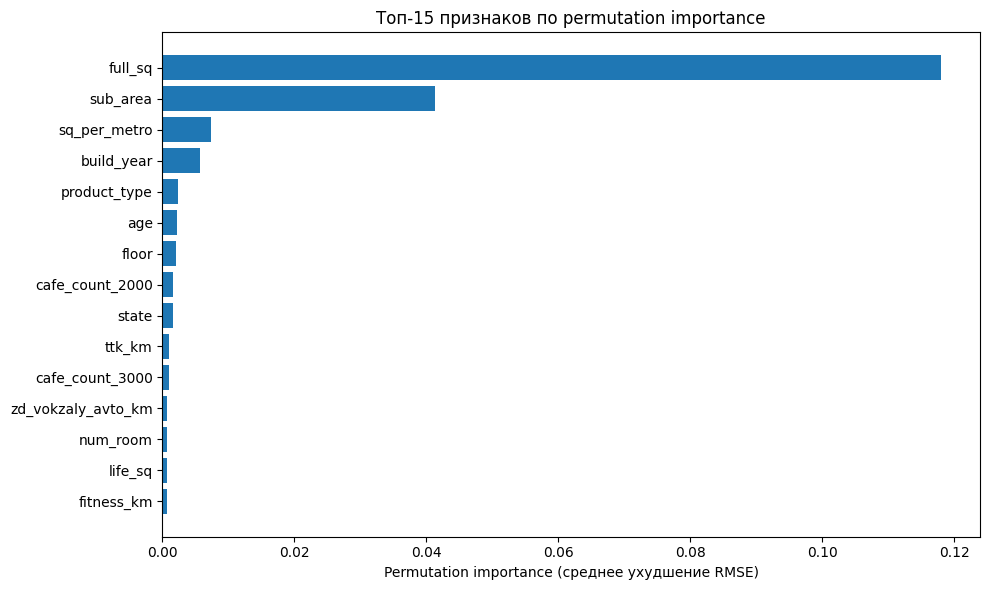

In [149]:
perm_importance = permutation_importance(
    model_with_feat, X_valid, y_valid,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)

# Сортировка по важности
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print("\nТоп-10 признаков по permutation importance (чем больше, тем важнее):")
print(feature_importance.head(10))

# Посмотрим место нового признака
print("\nРанг нового признака 'sq_per_metro':")
print(feature_importance[feature_importance['feature'] == 'sq_per_metro'])

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Permutation importance (среднее ухудшение RMSE)')
plt.title('Топ-15 признаков по permutation importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()